In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -U transformers --q
!pip install sentencepiece --q
!pip install tokenizers  --q
!pip install arabic-reshaper --q
!pip install python-bidi --q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 6.0 MB/s eta 0:00:00


In [ ]:
import re
import time
import torch
import random
import numpy as np
import unicodedata
import pandas as pd
import torch.nn as nn
import arabic_reshaper
import torch.nn.functional as F
#import matplotlib.pyplot as plt
#from wordcloud import WordCloud
from collections import Counter
from transformers import BertModel
from bidi.algorithm import get_display
from bidi.algorithm import get_display
from torch.optim import SparseAdam, Adam
from transformers import  AutoModelForSequenceClassification, AutoTokenizer ,BertTokenizer, BertForSequenceClassification,AutoModel
#from imblearn.over_sampling import RandomOverSampler
from transformers import TrainingArguments, Trainer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score,precision_recall_fscore_support
from transformers import AdamW, get_linear_schedule_with_warmup
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
%matplotlib inline

# **CamelBERT Without Overlap**

In [ ]:
import pandas as pd

# Load your dataset
data = pd.read_csv('Dataset_after_augmentation.csv')


In [ ]:
#without overlap
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
from sklearn.metrics import precision_recall_fscore_support

# Parameters and Model Initialization
model_name = "CAMeL-Lab/bert-base-arabic-camelbert-msa"
NUMBER_LABELS = 9  # Number of labels in your dataset
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUMBER_LABELS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def tokenize_with_stride(texts, tokenizer, max_length=512):
    input_ids = []
    attention_mask = []
    overflow_to_sample_mapping = []
    for i, text in enumerate(texts):
        tokenized = tokenizer(
            text,
            max_length=max_length,
            truncation=True,
            return_overflowing_tokens=True,
            return_tensors="pt",
            padding="max_length"
        )
        # Extend the tokenized outputs
        input_ids.append(tokenized.input_ids)
        attention_mask.append(tokenized.attention_mask)
        # Map each chunk back to its original text's index
        overflow_to_sample_mapping.extend([i] * tokenized.input_ids.size(0))

    # Concatenate the lists into tensors
    input_ids = torch.cat(input_ids, dim=0)
    attention_mask = torch.cat(attention_mask, dim=0)
    print(f"Total Chunks: {len(input_ids)}")
    print(f"Mapping Size: {len(overflow_to_sample_mapping)}")  # Should match the total number of chunks

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'overflow_to_sample_mapping': overflow_to_sample_mapping
    }

# Example Dataset Preparation
X = list(data["col2"])  # Your texts
y = data.iloc[:, 1:].values  # Your labels

# Split Data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Tokenize Data with Stride
train_encodings = tokenize_with_stride(X_train, tokenizer, MAX_LENGTH)
val_encodings = tokenize_with_stride(X_val, tokenizer, MAX_LENGTH)

class CustomDataset(Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels  # Ensure this is an array or a list

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items() if key != 'overflow_to_sample_mapping'}
        if self.labels is not None:
            sample_idx = self.encodings['overflow_to_sample_mapping'][idx]
            item['labels'] = torch.tensor(self.labels[sample_idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

# Create Datasets and DataLoaders
train_dataset = CustomDataset(train_encodings, y_train)
val_dataset = CustomDataset(val_encodings, y_val)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Training Loop
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(3):  # Example epoch count
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} completed.")

    # Evaluation
    model.eval()
    all_predictions = []
    all_true_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities > 0.5).int()
            all_predictions.append(predictions.cpu().numpy())
            all_true_labels.append(labels.cpu().numpy())

    # Concatenate all batches
    all_predictions = np.concatenate(all_predictions)
    all_true_labels = np.concatenate(all_true_labels)

    # Calculate Precision, Recall, and F1 Score
    precision, recall, f1, _ = precision_recall_fscore_support(all_true_labels, all_predictions, average='micro')
    print(f"Epoch {epoch} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/305k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-msa and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Total Chunks: 2183
Mapping Size: 2183
Total Chunks: 535
Mapping Size: 535
Epoch 0 completed.
Epoch 0 - Precision: 0.8665, Recall: 0.8509, F1 Score: 0.8586
Epoch 1 completed.
Epoch 1 - Precision: 0.8590, Recall: 0.9009, F1 Score: 0.8794
Epoch 2 completed.
Epoch 2 - Precision: 0.8965, Recall: 0.8328, F1 Score: 0.8635


# **CamelBERT With Overlap**

In [ ]:
#with overlap
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
from sklearn.metrics import precision_recall_fscore_support

# Parameters and Model Initialization
model_name = "CAMeL-Lab/bert-base-arabic-camelbert-msa"
NUMBER_LABELS = 9  # Number of labels in your dataset
MAX_LENGTH = 512
STRIDE = 100  # Stride for tokenization

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUMBER_LABELS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def tokenize_with_stride(texts, tokenizer, max_length=512, stride=100):
    input_ids = []
    attention_mask = []
    overflow_to_sample_mapping = []
    for i, text in enumerate(texts):
        tokenized = tokenizer(
            text,
            max_length=max_length,
            truncation=True,
            stride=stride,
            return_overflowing_tokens=True,
            return_tensors="pt",
            padding="max_length"
        )
        # Extend the tokenized outputs
        input_ids.append(tokenized.input_ids)
        attention_mask.append(tokenized.attention_mask)
        # Map each chunk back to its original text's index
        overflow_to_sample_mapping.extend([i] * tokenized.input_ids.size(0))

    # Concatenate the lists into tensors
    input_ids = torch.cat(input_ids, dim=0)
    attention_mask = torch.cat(attention_mask, dim=0)
    print(f"Total Chunks: {len(input_ids)}")
    print(f"Mapping Size: {len(overflow_to_sample_mapping)}")  # Should match the total number of chunks

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'overflow_to_sample_mapping': overflow_to_sample_mapping
    }

# Example Dataset Preparation
X = list(data["col2"])  # Your texts
y = data.iloc[:, 1:].values  # Your labels

# Split Data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Tokenize Data with Stride
train_encodings = tokenize_with_stride(X_train, tokenizer, MAX_LENGTH, STRIDE)
val_encodings = tokenize_with_stride(X_val, tokenizer, MAX_LENGTH, STRIDE)

class CustomDataset(Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels  # Ensure this is an array or a list

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items() if key != 'overflow_to_sample_mapping'}
        if self.labels is not None:
            sample_idx = self.encodings['overflow_to_sample_mapping'][idx]
            item['labels'] = torch.tensor(self.labels[sample_idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

# Create Datasets and DataLoaders
train_dataset = CustomDataset(train_encodings, y_train)
val_dataset = CustomDataset(val_encodings, y_val)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Training Loop
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(3):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} completed.")

    # Evaluation
    model.eval()
    all_predictions = []
    all_true_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities > 0.5).int()
            all_predictions.append(predictions.cpu().numpy())
            all_true_labels.append(labels.cpu().numpy())

    # Concatenate all batches
    all_predictions = np.concatenate(all_predictions)
    all_true_labels = np.concatenate(all_true_labels)

    # Calculate Precision, Recall, and F1 Score
    precision, recall, f1, _ = precision_recall_fscore_support(all_true_labels, all_predictions, average='micro')
    print(f"Epoch {epoch} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-msa and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total Chunks: 2303
Mapping Size: 2303
Total Chunks: 563
Mapping Size: 563
Epoch 0 completed.
Epoch 0 - Precision: 0.8659, Recall: 0.8677, F1 Score: 0.8668
Epoch 1 completed.
Epoch 1 - Precision: 0.8878, Recall: 0.8850, F1 Score: 0.8864
Epoch 2 completed.
Epoch 2 - Precision: 0.8895, Recall: 0.8741, F1 Score: 0.8817


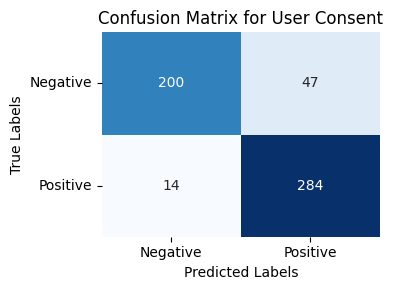

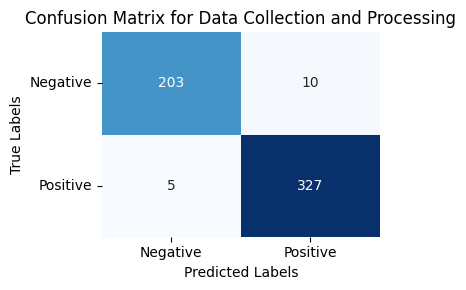

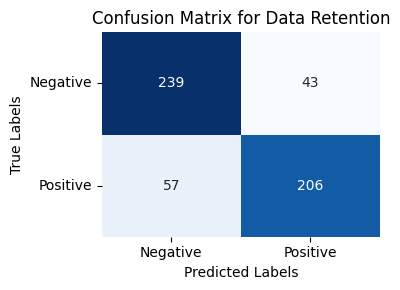

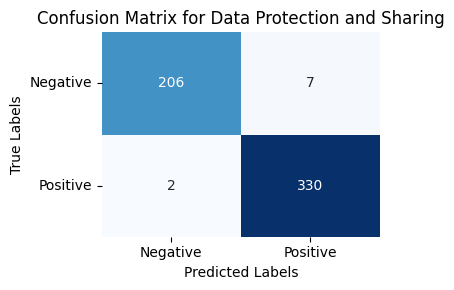

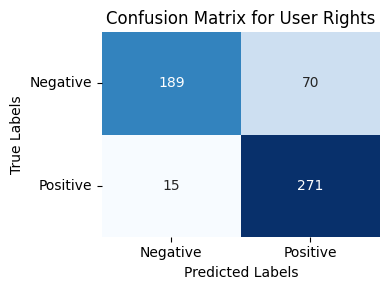

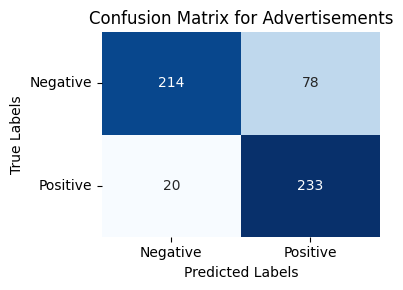

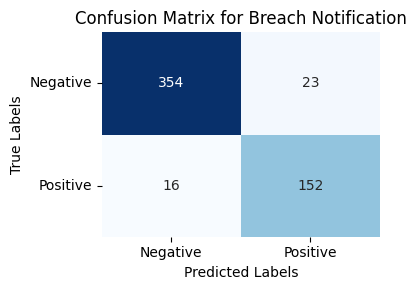

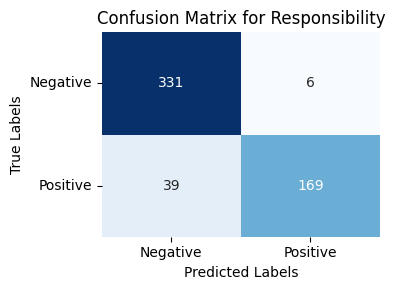

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already trained your model and obtained predictions and true labels
# Calculate confusion matrices for each label
multilabel_cms = multilabel_confusion_matrix(all_true_labels, all_predictions)

# List of descriptive label names
label_names = [
    "User Consent",
    "Data Collection and Processing",
    "Data Retention",
    "Data Protection and Sharing",
    "User Rights",
    "Advertisements",
    "Breach Notification",
    "Responsibility"
]

# Plotting heatmaps for each label's confusion matrix
for i, label_name in enumerate(label_names):
    plt.figure(figsize=(4, 3))  # Adjusted figure size for better readability
    sns.heatmap(multilabel_cms[i], annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {label_name}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.xticks([0.5, 1.5], labels=['Negative', 'Positive'])  # Adjust labels as needed
    plt.yticks([0.5, 1.5], labels=['Negative', 'Positive'], rotation=0)  # Adjust rotation and labels
    plt.tight_layout()  # Adjust layout to make sure everything fits without overlapping
    plt.show()

# **AraBERT Without Overlap**

In [ ]:
import pandas as pd

# Load your dataset
data = pd.read_csv('Dataset_after_augmentation.csv')


In [ ]:
#with overlap
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
from sklearn.metrics import precision_recall_fscore_support

# Parameters and Model Initialization
model_name = "aubmindlab/bert-base-arabertv02"
NUMBER_LABELS = 9  # Number of labels in your dataset
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUMBER_LABELS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def tokenize_with_stride(texts, tokenizer, max_length=512):
    input_ids = []
    attention_mask = []
    overflow_to_sample_mapping = []
    for i, text in enumerate(texts):
        tokenized = tokenizer(
            text,
            max_length=max_length,
            truncation=True,
            return_overflowing_tokens=True,
            return_tensors="pt",
            padding="max_length"
        )
        # Extend the tokenized outputs
        input_ids.append(tokenized.input_ids)
        attention_mask.append(tokenized.attention_mask)
        # Map each chunk back to its original text's index
        overflow_to_sample_mapping.extend([i] * tokenized.input_ids.size(0))

    # Concatenate the lists into tensors
    input_ids = torch.cat(input_ids, dim=0)
    attention_mask = torch.cat(attention_mask, dim=0)
    print(f"Total Chunks: {len(input_ids)}")
    print(f"Mapping Size: {len(overflow_to_sample_mapping)}")

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'overflow_to_sample_mapping': overflow_to_sample_mapping
    }

# Example Dataset Preparation
X = list(data["col2"])  # Your texts
y = data.iloc[:, 1:].values  # Your labels

# Split Data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Tokenize Data with Stride
train_encodings = tokenize_with_stride(X_train, tokenizer, MAX_LENGTH)
val_encodings = tokenize_with_stride(X_val, tokenizer, MAX_LENGTH)

class CustomDataset(Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels  # Ensure this is an array or a list

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items() if key != 'overflow_to_sample_mapping'}
        if self.labels is not None:
            sample_idx = self.encodings['overflow_to_sample_mapping'][idx]
            item['labels'] = torch.tensor(self.labels[sample_idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

# Create Datasets and DataLoaders
train_dataset = CustomDataset(train_encodings, y_train)
val_dataset = CustomDataset(val_encodings, y_val)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Training Loop
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(3):  # Example epoch count
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} completed.")

    # Evaluation
    model.eval()
    all_predictions = []
    all_true_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities > 0.5).int()
            all_predictions.append(predictions.cpu().numpy())
            all_true_labels.append(labels.cpu().numpy())

    # Concatenate all batches
    all_predictions = np.concatenate(all_predictions)
    all_true_labels = np.concatenate(all_true_labels)

    # Calculate Precision, Recall, and F1 Score
    precision, recall, f1, _ = precision_recall_fscore_support(all_true_labels, all_predictions, average='micro')
    print(f"Epoch {epoch} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total Chunks: 2092
Mapping Size: 2092
Total Chunks: 510
Mapping Size: 510
Epoch 0 completed.
Epoch 0 - Precision: 0.8320, Recall: 0.8377, F1 Score: 0.8348
Epoch 1 completed.
Epoch 1 - Precision: 0.8438, Recall: 0.8864, F1 Score: 0.8646
Epoch 2 completed.
Epoch 2 - Precision: 0.8641, Recall: 0.9034, F1 Score: 0.8833


# **AraBERT With Overlap**

In [ ]:
#with overlap
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
from sklearn.metrics import precision_recall_fscore_support

# Parameters and Model Initialization
model_name = "aubmindlab/bert-base-arabertv02"
NUMBER_LABELS = 9  # Number of labels in your dataset
MAX_LENGTH = 512
STRIDE = 100  # Stride for tokenization

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUMBER_LABELS)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def tokenize_with_stride(texts, tokenizer, max_length=512, stride=100):
    input_ids = []
    attention_mask = []
    overflow_to_sample_mapping = []
    for i, text in enumerate(texts):
        tokenized = tokenizer(
            text,
            max_length=max_length,
            truncation=True,
            stride=stride,
            return_overflowing_tokens=True,
            return_tensors="pt",
            padding="max_length"
        )
        # Extend the tokenized outputs
        input_ids.append(tokenized.input_ids)
        attention_mask.append(tokenized.attention_mask)
        # Map each chunk back to its original text's index
        overflow_to_sample_mapping.extend([i] * tokenized.input_ids.size(0))

    # Concatenate the lists into tensors
    input_ids = torch.cat(input_ids, dim=0)
    attention_mask = torch.cat(attention_mask, dim=0)
    print(f"Total Chunks: {len(input_ids)}")
    print(f"Mapping Size: {len(overflow_to_sample_mapping)}")  # Should match the total number of chunks

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'overflow_to_sample_mapping': overflow_to_sample_mapping
    }

# Example Dataset Preparation
X = list(data["col2"])  # Your texts
y = data.iloc[:, 1:].values  # Your labels

# Split Data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Tokenize Data with Stride
train_encodings = tokenize_with_stride(X_train, tokenizer, MAX_LENGTH, STRIDE)
val_encodings = tokenize_with_stride(X_val, tokenizer, MAX_LENGTH, STRIDE)

class CustomDataset(Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels  # Ensure this is an array or a list

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items() if key != 'overflow_to_sample_mapping'}
        if self.labels is not None:
            sample_idx = self.encodings['overflow_to_sample_mapping'][idx]
            item['labels'] = torch.tensor(self.labels[sample_idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

# Create Datasets and DataLoaders
train_dataset = CustomDataset(train_encodings, y_train)
val_dataset = CustomDataset(val_encodings, y_val)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Training Loop
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(3):
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch} completed.")

    # Evaluation
    model.eval()
    all_predictions = []
    all_true_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities > 0.5).int()
            all_predictions.append(predictions.cpu().numpy())
            all_true_labels.append(labels.cpu().numpy())

    # Concatenate all batches
    all_predictions = np.concatenate(all_predictions)
    all_true_labels = np.concatenate(all_true_labels)

    # Calculate Precision, Recall, and F1 Score
    precision, recall, f1, _ = precision_recall_fscore_support(all_true_labels, all_predictions, average='micro')
    print(f"Epoch {epoch} - Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total Chunks: 2200
Mapping Size: 2200
Total Chunks: 533
Mapping Size: 533
Epoch 0 completed.
Epoch 0 - Precision: 0.8931, Recall: 0.7259, F1 Score: 0.8009
Epoch 1 completed.
Epoch 1 - Precision: 0.8454, Recall: 0.9174, F1 Score: 0.8800
Epoch 2 completed.
Epoch 2 - Precision: 0.8716, Recall: 0.8980, F1 Score: 0.8846
